### Filter out data such that it has all 3 positions

In [1]:
import pandas as pd

In [2]:
normalized_counts = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/data/GTeX_experimental_data/OL41_42_20221220_K562_normalized_counts.out", sep=r"\s+", header=None)
normalized_counts.columns = ["seq_id", "plasmid_r1", "plasmid_r2", "plasmid_r3", "plasmid_r4","plasmid_r5", "k562_r1", "k562_r2","k562_r3","k562_r4","k562_r5","k562_r6"]

In [3]:
normalized_counts['base_id'] = normalized_counts['seq_id'].str.extract(r'(^[^:]+:[^:]+:[^:]+:[^:]+:[^:]+)')

# Extract strand (wC/wR/wL)
normalized_counts['strand'] = normalized_counts['seq_id'].str.extract(r'(:w[CRL])$')

# Count unique strands per base_id
strand_counts = normalized_counts.groupby('base_id')['strand'].nunique()

# Filter to base_ids that have all 3 strand types
valid_base_ids = strand_counts[strand_counts == 3].index

# Filter original DataFrame
filtered_normalized_counts = normalized_counts[normalized_counts['base_id'].isin(valid_base_ids)].drop(columns=['base_id', 'strand'])


In [4]:
normalized_counts["base_id"]

0          (1:1009223:C:T:A
1          (1:1009223:C:T:R
2          (1:1009234:T:C:A
3          (1:1009234:T:C:R
4         (1:10490539:G:C:A
                ...        
470790     X:99996102:A:G:R
470791     X:99998829:C:T:A
470792     X:99998829:C:T:R
470793     X:99999349:G:A:A
470794     X:99999349:G:A:R
Name: base_id, Length: 470795, dtype: object

In [5]:
filtered_normalized_counts

,seq_id,plasmid_r1,plasmid_r2,plasmid_r3,plasmid_r4,plasmid_r5,k562_r1,k562_r2,k562_r3,k562_r4,k562_r5,k562_r6
64156,10:35356774:A:G:A:wC,639.489215,581.733485,698.255434,764.010394,682.295625,4907.138349,3487.939688,2623.750170,3490.092610,3854.435635,3440.346915
64157,10:35356774:A:G:A:wL,1150.659871,1134.984470,1028.928719,1062.272710,1195.362800,10291.525824,8391.590845,5791.879997,8933.684156,8872.252757,7422.358108
64158,10:35356774:A:G:A:wR,319.043413,340.926894,357.790001,408.389940,261.915411,378.507928,371.818727,422.265143,510.708944,340.788517,527.819823
64159,10:35356774:A:G:R:wC,735.552837,852.748788,674.151686,724.242085,516.057077,3295.861519,2182.684827,1637.703999,2388.271564,2262.970051,2640.829674
64160,10:35356774:A:G:R:wL,498.549158,534.262651,515.970844,529.224417,472.404508,2212.700493,1882.429537,1634.280228,1882.029462,1873.497460,1531.542766
...,...,...,...,...,...,...,...,...,...,...,...,...
446469,9:131038575:G:C:A:wL,409.497480,365.093864,353.270548,370.151182,368.355920,4917.610900,5266.135523,5077.453026,3979.956292,4653.525950,4137.761305
446470,9:131038575:G:C:A:wR,527.999319,457.446212,492.620338,510.105038,525.624763,54164.035607,74992.259009,63796.274252,52144.425472,54519.447597,54252.955626
446471,9:131038575:G:C:R:wC,360.413878,296.908485,306.569538,348.737477,293.010391,17367.978383,19566.377096,18069.524333,17370.059894,16893.373604,14171.529621
446472,9:131038575:G:C:R:wL,362.517461,347.831742,373.608085,464.983303,395.863018,2854.518284,3624.843654,3342.742170,3323.330506,3375.988703,2632.176890


### Now make sure both alleles present

In [6]:
df = filtered_normalized_counts.copy()

df[['chr', 'pos', 'ref', 'alt', 'allele', 'strand']] = df['seq_id'].str.extract(
    r'([^:]+):([^:]+):([^:]+):([^:]+):([^:]+):(w[C|L|R])'
)

df['base_id'] = df[['chr', 'pos', 'ref', 'alt', 'strand']].agg(':'.join, axis=1)

allele_counts = df.groupby(['base_id', 'allele']).size().unstack(fill_value=0)

valid_base_ids = allele_counts[(allele_counts['A'] > 0) & (allele_counts['R'] > 0)].index

df_filtered = df[df['base_id'].isin(valid_base_ids)]

df_filtered = df_filtered.drop(columns=['chr', 'pos', 'ref', 'alt', 'allele', 'strand', 'base_id'])

In [7]:
df_filtered

,seq_id,plasmid_r1,plasmid_r2,plasmid_r3,plasmid_r4,plasmid_r5,k562_r1,k562_r2,k562_r3,k562_r4,k562_r5,k562_r6
64156,10:35356774:A:G:A:wC,639.489215,581.733485,698.255434,764.010394,682.295625,4907.138349,3487.939688,2623.750170,3490.092610,3854.435635,3440.346915
64157,10:35356774:A:G:A:wL,1150.659871,1134.984470,1028.928719,1062.272710,1195.362800,10291.525824,8391.590845,5791.879997,8933.684156,8872.252757,7422.358108
64158,10:35356774:A:G:A:wR,319.043413,340.926894,357.790001,408.389940,261.915411,378.507928,371.818727,422.265143,510.708944,340.788517,527.819823
64159,10:35356774:A:G:R:wC,735.552837,852.748788,674.151686,724.242085,516.057077,3295.861519,2182.684827,1637.703999,2388.271564,2262.970051,2640.829674
64160,10:35356774:A:G:R:wL,498.549158,534.262651,515.970844,529.224417,472.404508,2212.700493,1882.429537,1634.280228,1882.029462,1873.497460,1531.542766
...,...,...,...,...,...,...,...,...,...,...,...,...
446469,9:131038575:G:C:A:wL,409.497480,365.093864,353.270548,370.151182,368.355920,4917.610900,5266.135523,5077.453026,3979.956292,4653.525950,4137.761305
446470,9:131038575:G:C:A:wR,527.999319,457.446212,492.620338,510.105038,525.624763,54164.035607,74992.259009,63796.274252,52144.425472,54519.447597,54252.955626
446471,9:131038575:G:C:R:wC,360.413878,296.908485,306.569538,348.737477,293.010391,17367.978383,19566.377096,18069.524333,17370.059894,16893.373604,14171.529621
446472,9:131038575:G:C:R:wL,362.517461,347.831742,373.608085,464.983303,395.863018,2854.518284,3624.843654,3342.742170,3323.330506,3375.988703,2632.176890


### Perform FDR and filter out for < 10%

In [8]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# Define replicate columns
plasmid_cols = [f'plasmid_r{i}' for i in range(1, 6)]
k562_cols = [f'k562_r{i}' for i in range(1, 6)]  # drop k562_r6

# Extract window and strand
df_filtered['window_id'] = df_filtered['seq_id'].str.extract(r'^(\d+:\d+)')
df_filtered['strand'] = df_filtered['seq_id'].str.extract(r'(w[CRL])$')

df_filtered['allele_type'] = df_filtered['seq_id'].apply(lambda x: 'ref' if ':R:' in x else 'alt')

# Make group key
df_filtered['window_strand'] = df_filtered['window_id'] + ':' + df_filtered['strand']

# Initialize results
results = []

# Group by window + strand
for group_id, group in df_filtered.groupby('window_strand'):
    ref = group[group['allele_type'] == 'ref']
    alt = group[group['allele_type'] == 'alt']
    
    # Match by window_id
    merged = pd.merge(ref, alt, on='window_id', suffixes=('_ref', '_alt'))
    
    for _, row in merged.iterrows():
        try:
            plasmid_ref = row[[f'{col}_ref' for col in plasmid_cols]].values.astype(float)
            k562_ref = row[[f'{col}_ref' for col in k562_cols]].values.astype(float)
            plasmid_alt = row[[f'{col}_alt' for col in plasmid_cols]].values.astype(float)
            k562_alt = row[[f'{col}_alt' for col in k562_cols]].values.astype(float)

            log2_ref = np.log2((k562_ref+1 )/(plasmid_ref+1))
            log2_alt = np.log2((k562_alt+1) / (plasmid_alt+1))

            stat, pval = ttest_ind(log2_ref, log2_alt, equal_var=False)

            results.append({
                'window_strand': group_id,
                'seq_id_ref': row['seq_id_ref'],
                'seq_id_alt': row['seq_id_alt'],
                'log2_fc_ref_mean': log2_ref.mean(),
                'log2_fc_alt_mean': log2_alt.mean(),
                'pval': pval
            })
        except:
            continue

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction within each window+strand group
results_df['fdr'] = results_df.groupby('window_strand')['pval'].transform(
    lambda x: multipletests(x, method='fdr_bh')[1]
)


In [9]:
results_df

,window_strand,seq_id_ref,seq_id_alt,log2_fc_ref_mean,log2_fc_alt_mean,pval,fdr
0,10:35356774:wC,10:35356774:A:G:R:wC,10:35356774:A:G:A:wC,1.729376,2.422908,0.026580,0.026580
1,10:35356774:wL,10:35356774:A:G:R:wL,10:35356774:A:G:A:wL,1.887585,2.899687,0.000154,0.000154
2,10:35356774:wR,10:35356774:A:G:R:wR,10:35356774:A:G:A:wR,0.024113,0.261885,0.090236,0.090236
3,12:112378909:wC,12:112378909:C:T:R:wC,12:112378909:C:T:A:wC,2.752861,2.403607,0.081136,0.081136
4,12:112378909:wL,12:112378909:C:T:R:wL,12:112378909:C:T:A:wL,2.655197,2.400354,0.308720,0.308720
...,...,...,...,...,...,...,...
133,9:123634040:wL,9:123634040:G:A:R:wL,9:123634040:G:A:A:wL,4.440214,3.810892,0.041542,0.041542
134,9:123634040:wR,9:123634040:G:A:R:wR,9:123634040:G:A:A:wR,0.867017,1.069783,0.302301,0.302301
135,9:131038575:wC,9:131038575:G:C:R:wC,9:131038575:G:C:A:wC,5.795908,6.389818,0.001326,0.001326
136,9:131038575:wL,9:131038575:G:C:R:wL,9:131038575:G:C:A:wL,3.086623,3.669918,0.001417,0.001417


In [10]:
results_df["base_id"] = results_df["window_strand"].str.extract(r"^([^:]+:[^:]+)")
filtered_results = results_df.groupby("base_id").filter(lambda group: (group["fdr"] < 0.1).any())

In [11]:
filtered_results

,window_strand,seq_id_ref,seq_id_alt,log2_fc_ref_mean,log2_fc_alt_mean,pval,fdr,base_id
0,10:35356774:wC,10:35356774:A:G:R:wC,10:35356774:A:G:A:wC,1.729376,2.422908,0.026580,0.026580,10:35356774
1,10:35356774:wL,10:35356774:A:G:R:wL,10:35356774:A:G:A:wL,1.887585,2.899687,0.000154,0.000154,10:35356774
2,10:35356774:wR,10:35356774:A:G:R:wR,10:35356774:A:G:A:wR,0.024113,0.261885,0.090236,0.090236,10:35356774
3,12:112378909:wC,12:112378909:C:T:R:wC,12:112378909:C:T:A:wC,2.752861,2.403607,0.081136,0.081136,12:112378909
4,12:112378909:wL,12:112378909:C:T:R:wL,12:112378909:C:T:A:wL,2.655197,2.400354,0.308720,0.308720,12:112378909
...,...,...,...,...,...,...,...,...
133,9:123634040:wL,9:123634040:G:A:R:wL,9:123634040:G:A:A:wL,4.440214,3.810892,0.041542,0.041542,9:123634040
134,9:123634040:wR,9:123634040:G:A:R:wR,9:123634040:G:A:A:wR,0.867017,1.069783,0.302301,0.302301,9:123634040
135,9:131038575:wC,9:131038575:G:C:R:wC,9:131038575:G:C:A:wC,5.795908,6.389818,0.001326,0.001326,9:131038575
136,9:131038575:wL,9:131038575:G:C:R:wL,9:131038575:G:C:A:wL,3.086623,3.669918,0.001417,0.001417,9:131038575


### Calculate variant effect

In [12]:
filtered_results["variant_effects"] = filtered_results["log2_fc_ref_mean"] - filtered_results["log2_fc_alt_mean"]

In [13]:
filtered_results['window_code'] = filtered_results['window_strand'].str.extract(r'(w[CLR])$')

pivot_filtered_results = filtered_results.pivot(index='base_id', columns='window_code', values='variant_effects')

pivot_filtered_results = pivot_filtered_results.rename(columns={
    'wL': 'left',
    'wR': 'right',
    'wC': 'centre'
}).reset_index()

pivot_filtered_results = pivot_filtered_results.dropna()

In [14]:
pivot_filtered_results

window_code,base_id,centre,left,right
0,10:35356774,-0.693531,-1.012101,-0.237772
1,12:112378909,0.349255,0.254843,-0.149317
2,12:54955169,1.740341,1.432356,1.320549
3,13:43597706,1.959047,2.011857,2.093779
4,15:44081143,1.764616,0.160185,2.246451
5,15:52796861,0.141461,-0.160049,-0.442300
6,15:65059651,-0.809087,-0.731372,-1.260198
7,15:82258451,0.999442,1.296703,-0.059475
8,16:1586255,-1.596110,-2.060755,-1.076794
9,17:43685021,0.695492,0.507835,-0.353550


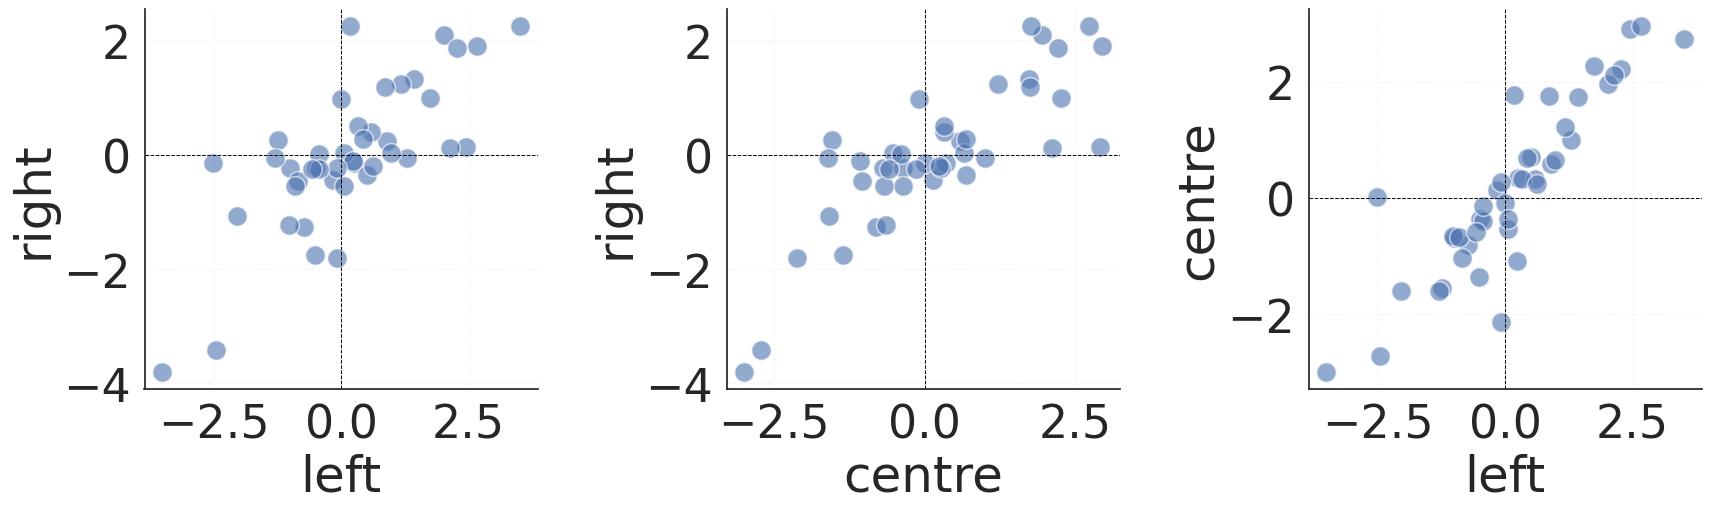

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Set Seaborn style
sns.set(style="white", font_scale=3)

def plot_scatter_with_r2(ax, df, x_col, y_col):
    valid_df = df[[x_col, y_col]].dropna()
    r, _ = pearsonr(valid_df[x_col], valid_df[y_col])
    r2 = r**2
    n_points = len(valid_df)-1

    # Scatterplot
    sns.scatterplot(
        x=valid_df[x_col], y=valid_df[y_col], ax=ax,
        color="#4C72B0", edgecolor="white", s=200, alpha=0.6
    )

    # Reference lines
    ax.axhline(0, color='black', linestyle='--', linewidth=0.7)
    ax.axvline(0, color='black', linestyle='--', linewidth=0.7)

    # Aesthetic tweaks
    ax.grid(True, linestyle=':', alpha=0.3)
    sns.despine(ax=ax)

# Set up figure
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot each pair
plot_scatter_with_r2(axs[0], pivot_filtered_results, 'left', 'right')
plot_scatter_with_r2(axs[1], pivot_filtered_results, 'centre', 'right')
plot_scatter_with_r2(axs[2], pivot_filtered_results, 'left', 'centre')

plt.tight_layout()
plt.savefig(f"/scratch/st-cdeboer-1/sambina/position_mpra/outputs/1-GTeX_experimental_variant_effect/corr.svg", format="svg")
plt.show()


In [16]:
print(pivot_filtered_results)
pivot_filtered_results.to_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/1-GTeX_experimental_variant_effect/42_variants.csv")

window_code       base_id    centre      left     right
0             10:35356774 -0.693531 -1.012101 -0.237772
1            12:112378909  0.349255  0.254843 -0.149317
2             12:54955169  1.740341  1.432356  1.320549
3             13:43597706  1.959047  2.011857  2.093779
4             15:44081143  1.764616  0.160185  2.246451
5             15:52796861  0.141461 -0.160049 -0.442300
6             15:65059651 -0.809087 -0.731372 -1.260198
7             15:82258451  0.999442  1.296703 -0.059475
8              16:1586255 -1.596110 -2.060755 -1.076794
9             17:43685021  0.695492  0.507835 -0.353550
10            17:43812218  2.275134  1.737231  0.993269
11            17:43838710 -0.359129 -0.491042 -0.229417
12            17:43950394 -2.128374 -0.089961 -1.799166
13            17:44139190  2.911350  2.451373  0.129620
14            17:44291820 -0.531083  0.043914  0.027971
15            17:44295052 -1.077652  0.220052 -0.112437
16            17:46983171 -1.542875 -1.241508  0

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def create_heatmap(df, title, output_file):
    plt.figure(figsize=(12, 10), dpi=300)
    pearson_corr = df.corr("pearson")
    r_squared_matrix = pearson_corr**2
    mask = np.triu(np.ones_like(r_squared_matrix, dtype=bool))

    # Remove rows and columns that are fully masked
    unmasked_rows = ~np.all(mask, axis=1)
    unmasked_cols = ~np.all(mask, axis=0)
    trimmed_matrix = r_squared_matrix.loc[unmasked_rows, unmasked_cols]
    trimmed_mask = mask[unmasked_rows, :][:, unmasked_cols]

    colors = ["#053061", "#2166ac", "#4393c3", "#92c5de", "#d1e5f0", 
              "#f7f7f7", "#fddbc7", "#f4a582", "#d6604d", "#b2182b", "#67001f"]
    cmap = LinearSegmentedColormap.from_list("custom", colors, N=100)
    
    ax = sns.heatmap(
        trimmed_matrix, 
        annot=True, 
        mask=trimmed_mask, 
        cmap=cmap, 
        vmin=0, 
        vmax=1,
        square=True, 
        linewidths=0.5, 
        cbar_kws={"label": "Pearson R²\n(Variance Explained)", "shrink": 0.8},
        annot_kws={"size": 12, "weight": "bold"},
        fmt='.2f'  
    )
    
    ax.figure.axes[-1].yaxis.label.set_size(12)  
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    plt.title(title, fontsize=18, fontweight='bold', pad=25)
    plt.tight_layout()
    plt.savefig(output_file, format="svg")
    plt.close()

In [18]:
heatmap_df = pivot_filtered_results[[
    "left",
    "centre",
    "right"
]].dropna()

create_heatmap(
    df=heatmap_df,
    title=f"K562 GTEx variants (n={len(heatmap_df)-1}) variants",
    output_file="/scratch/st-cdeboer-1/sambina/position_mpra/outputs/1-GTeX_experimental_variant_effect/heatmap.svg"
)

### Now doing interreplicate correlation

In [19]:
from itertools import combinations
from scipy.stats import pearsonr
import numpy as np
import pandas as pd

# Step 1: Filter df_filtered to only rows matching results_df
valid_seq_ids = set(filtered_results['seq_id_ref']).union(set(filtered_results['seq_id_alt']))
df_bootstrap = df_filtered[df_filtered['seq_id'].isin(valid_seq_ids)].copy()

# Step 2: All 10 combinations of splitting 5 replicates into groups of 2 and 3
replicate_indices = list(range(5))  # indices 0-4 corresponding to r1-r5
all_splits = [(list(combo), [i for i in replicate_indices if i not in combo])
              for combo in combinations(replicate_indices, 2)]  # group of 2 vs group of 3

plasmid_cols = [f'plasmid_r{i}' for i in range(1, 6)]
k562_cols    = [f'k562_r{i}'   for i in range(1, 6)]

def compute_variant_effects(df_input, rep_indices):
    """Compute per-base_id variant effects using a subset of replicates."""
    sel_plasmid = [plasmid_cols[i] for i in rep_indices]
    sel_k562    = [k562_cols[i]    for i in rep_indices]
    
    records = []
    for group_id, group in df_input.groupby('window_strand'):
        ref = group[group['allele_type'] == 'ref']
        alt = group[group['allele_type'] == 'alt']
        merged = pd.merge(ref, alt, on='window_id', suffixes=('_ref', '_alt'))
        
        for _, row in merged.iterrows():
            try:
                plasmid_ref = row[[f'{c}_ref' for c in sel_plasmid]].values.astype(float)
                k562_ref    = row[[f'{c}_ref' for c in sel_k562]].values.astype(float)
                plasmid_alt = row[[f'{c}_alt' for c in sel_plasmid]].values.astype(float)
                k562_alt    = row[[f'{c}_alt' for c in sel_k562]].values.astype(float)

                log2_ref = np.log2((k562_ref + 1) / (plasmid_ref + 1))
                log2_alt = np.log2((k562_alt + 1) / (plasmid_alt + 1))

                records.append({
                    'window_strand': group_id,
                    'base_id': group_id.rsplit(':', 1)[0],  # strip strand
                    'variant_effect': log2_ref.mean() - log2_alt.mean()
                })
            except:
                continue

    res = pd.DataFrame(records)

    # Aggregate across strands per base_id (mean variant effect)
    return res.groupby('base_id')['variant_effect'].mean()


# Step 3: Run all 10 splits and compute Pearson R²
bootstrap_results = []

for split_idx, (group_a_idx, group_b_idx) in enumerate(all_splits):
    ve_a = compute_variant_effects(df_bootstrap, group_a_idx)
    ve_b = compute_variant_effects(df_bootstrap, group_b_idx)

    # Align on shared base_ids
    common = ve_a.index.intersection(ve_b.index)
    if len(common) < 3:
        continue

    r, pval = pearsonr(ve_a[common], ve_b[common])
    bootstrap_results.append({
        'split': split_idx,
        'group_a': [i+1 for i in group_a_idx],  # back to 1-indexed rep numbers
        'group_b': [i+1 for i in group_b_idx],
        'n_variants': len(common),
        'pearson_r': r,
        'r_squared': r**2,
        'pval': pval
    })

bootstrap_df = pd.DataFrame(bootstrap_results)

print(bootstrap_df[['group_a', 'group_b', 'n_variants', 'pearson_r', 'r_squared']].to_string(index=False))
print(f"\nMean R²: {bootstrap_df['r_squared'].mean():.4f}  ±  {bootstrap_df['r_squared'].std():.4f}")

group_a   group_b  n_variants  pearson_r  r_squared
 [1, 2] [3, 4, 5]          43   0.987457   0.975071
 [1, 3] [2, 4, 5]          43   0.992802   0.985657
 [1, 4] [2, 3, 5]          43   0.977158   0.954837
 [1, 5] [2, 3, 4]          43   0.995228   0.990479
 [2, 3] [1, 4, 5]          43   0.988660   0.977448
 [2, 4] [1, 3, 5]          43   0.988597   0.977325
 [2, 5] [1, 3, 4]          43   0.982795   0.965886
 [3, 4] [1, 2, 5]          43   0.991432   0.982937
 [3, 5] [1, 2, 4]          43   0.981548   0.963437
 [4, 5] [1, 2, 3]          43   0.993993   0.988021

Mean R²: 0.9761  ±  0.0116


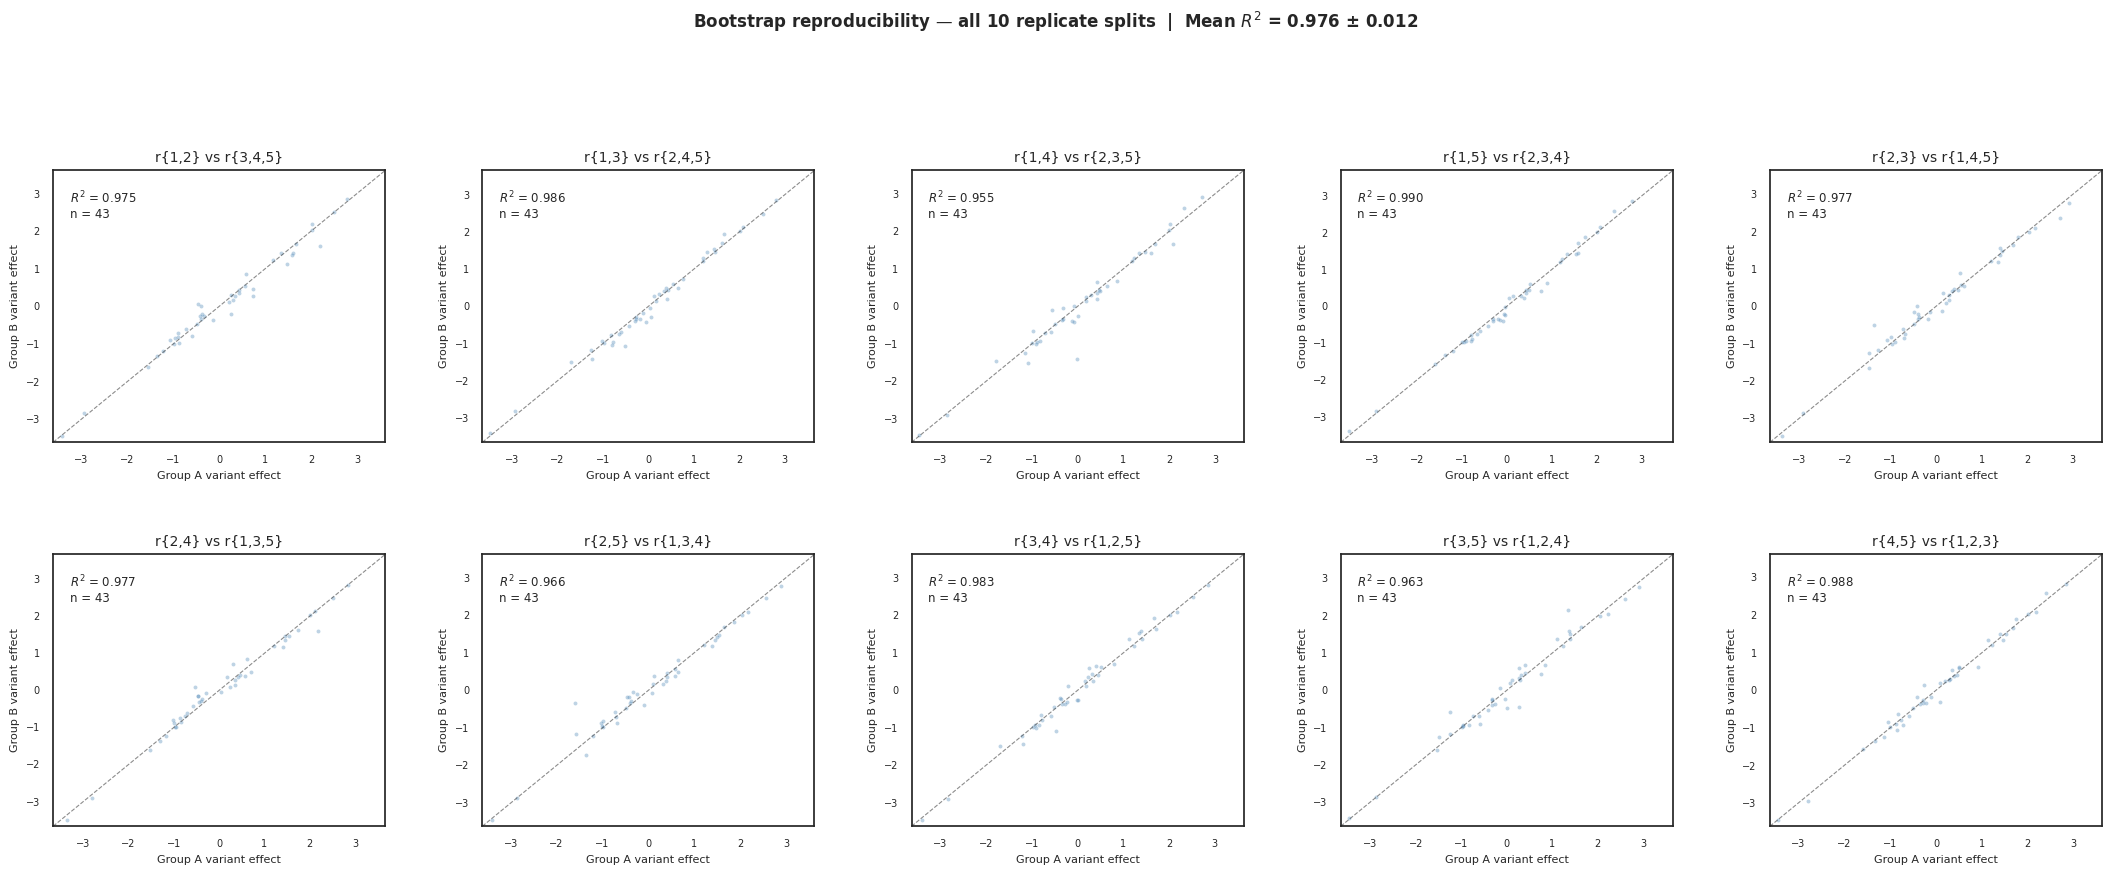

In [20]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
import numpy as np

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for split_idx, (group_a_idx, group_b_idx) in enumerate(all_splits):
    ve_a = compute_variant_effects(df_bootstrap, group_a_idx)
    ve_b = compute_variant_effects(df_bootstrap, group_b_idx)

    common = ve_a.index.intersection(ve_b.index)
    if len(common) < 3:
        continue

    x = ve_a[common].values
    y = ve_b[common].values
    r, pval = pearsonr(x, y)

    ax = axes[split_idx]

    # Scatter
    ax.scatter(x, y, alpha=0.35, s=8, color='steelblue', linewidths=0)

    # Identity line
    lim = max(abs(x).max(), abs(y).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8, alpha=0.5)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

    # Labels
    group_a_str = ','.join(map(str, [i+1 for i in group_a_idx]))
    group_b_str = ','.join(map(str, [i+1 for i in group_b_idx]))
    ax.set_title(f'r{{{group_a_str}}} vs r{{{group_b_str}}}', fontsize=10)
    ax.set_xlabel('Group A variant effect', fontsize=8)
    ax.set_ylabel('Group B variant effect', fontsize=8)
    ax.tick_params(labelsize=7)

    # Annotate R²
    ax.text(0.05, 0.93, f'$R^2$ = {r**2:.3f}\nn = {len(common):,}',
            transform=ax.transAxes, fontsize=8.5,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

mean_r2 = np.mean([pearsonr(
    compute_variant_effects(df_bootstrap, a)[compute_variant_effects(df_bootstrap, a).index.intersection(
     compute_variant_effects(df_bootstrap, b).index)].values,
    compute_variant_effects(df_bootstrap, b)[compute_variant_effects(df_bootstrap, a).index.intersection(
     compute_variant_effects(df_bootstrap, b).index)].values
)[0]**2 for a, b in all_splits])

fig.suptitle(
    f'Bootstrap reproducibility — all 10 replicate splits  |  Mean $R^2$ = {bootstrap_df["r_squared"].mean():.3f} ± {bootstrap_df["r_squared"].std():.3f}',
    fontsize=12, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.show()

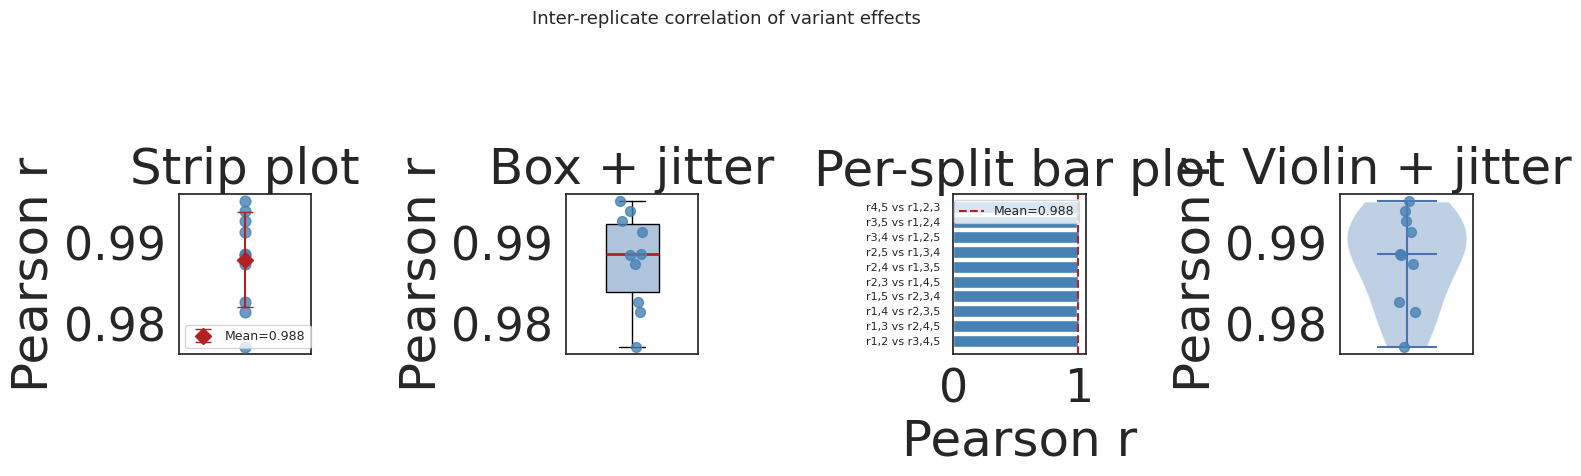

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

# 1. Strip/dot plot with mean ± SD
ax = axes[0]
ax.scatter(np.zeros(len(bootstrap_df)), bootstrap_df['pearson_r'], 
           color='steelblue', s=60, zorder=3, alpha=0.8)
mean_r, sd_r = bootstrap_df['pearson_r'].mean(), bootstrap_df['pearson_r'].std()
ax.errorbar(0, mean_r, yerr=sd_r, fmt='D', color='firebrick', 
            capsize=6, markersize=8, zorder=4, label=f'Mean={mean_r:.3f}')
ax.set_xlim(-0.5, 0.5)
ax.set_xticks([])
ax.set_ylabel('Pearson r')
ax.set_title('Strip plot')
ax.legend(fontsize=9)

# 2. Box + jitter
ax = axes[1]
ax.boxplot(bootstrap_df['pearson_r'], widths=0.4, patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'), medianprops=dict(color='firebrick', linewidth=2))
jitter = np.random.uniform(-0.1, 0.1, size=len(bootstrap_df))
ax.scatter(1 + jitter, bootstrap_df['pearson_r'], color='steelblue', s=50, zorder=3, alpha=0.8)
ax.set_xticks([])
ax.set_ylabel('Pearson r')
ax.set_title('Box + jitter')

# 3. Bar plot with each split labeled
ax = axes[2]
labels = [f"r{','.join(map(str,row.group_a))} vs r{','.join(map(str,row.group_b))}" 
          for row in bootstrap_df.itertuples()]
ax.barh(range(len(bootstrap_df)), bootstrap_df['pearson_r'], color='steelblue', edgecolor='white')
ax.axvline(mean_r, color='firebrick', linestyle='--', linewidth=1.5, label=f'Mean={mean_r:.3f}')
ax.set_yticks(range(len(bootstrap_df)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Pearson r')
ax.set_title('Per-split bar plot')
ax.legend(fontsize=9)

# 4. Violin (with jitter since n=10)
ax = axes[3]
parts = ax.violinplot(bootstrap_df['pearson_r'], positions=[0], showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('lightsteelblue')
    pc.set_alpha(0.8)
jitter = np.random.uniform(-0.05, 0.05, size=len(bootstrap_df))
ax.scatter(jitter, bootstrap_df['pearson_r'], color='steelblue', s=50, zorder=3, alpha=0.8)
ax.set_xticks([])
ax.set_ylabel('Pearson r')
ax.set_title('Violin + jitter')

plt.suptitle('Inter-replicate correlation of variant effects', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('bootstrap_pearson_r_all.png', dpi=150, bbox_inches='tight')
plt.show()

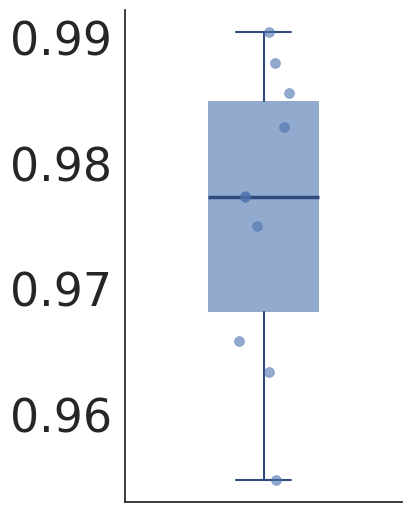

In [31]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(5, 6))

darker_blue = "#2E4A7A"

ax.boxplot(bootstrap_df['r_squared'], widths=0.4, patch_artist=True,
           boxprops=dict(facecolor='#4C72B0', alpha=0.6, linewidth=0),
           medianprops=dict(color=darker_blue, linewidth=2.5),
           whiskerprops=dict(color=darker_blue, linewidth=1.5),
           capprops=dict(color=darker_blue, linewidth=1.5),
           flierprops=dict(marker=''))

np.random.seed(42)
jitter = np.random.uniform(-0.1, 0.1, size=len(bootstrap_df))
ax.scatter(1 + jitter, bootstrap_df['r_squared'],
           color='#4C72B0', s=50, zorder=3, alpha=0.6, linewidth=0.5)

ax.set_xticks([])
# ax.set_ylabel('Pearson r', fontsize=13)
# ax.set_title('Inter-replicate correlation\nof variant effects', fontsize=13)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/scratch/st-cdeboer-1/sambina/position_mpra/outputs/1-GTeX_experimental_variant_effect/bootstrap_pearson_r_boxjitter.svg', format="svg", dpi=150)
plt.show()

In [23]:
# import pandas as pd
# import numpy as np
# from scipy.stats import ttest_ind, pearsonr
# from statsmodels.stats.multitest import multipletests
# import random


# r_list = []

# for _ in range(10):
    
#     plasmid_indices = list(range(1, 6))
#     k562_indices = list(range(1, 6))
#     random.shuffle(plasmid_indices)
#     random.shuffle(k562_indices)

#     # Randomly split into two sets
#     plasmid_cols_rep1 = [f'plasmid_r{i}' for i in plasmid_indices[:3]]
#     plasmid_cols_rep2 = [f'plasmid_r{i}' for i in plasmid_indices[3:]]

#     k562_cols_rep1 = [f'k562_r{i}' for i in k562_indices[:3]]
#     k562_cols_rep2 = [f'k562_r{i}' for i in k562_indices[3:]]

#     # Make a copy of df if you're modifying in-place
#     df_copy = df.copy()

#     # Extract window and strand
#     df_copy['window_id'] = df_copy['seq_id'].str.extract(r'^(\d+:\d+)')
#     df_copy['strand'] = df_copy['seq_id'].str.extract(r'(w[CRL])$')
#     df_copy['allele_type'] = df_copy['seq_id'].apply(lambda x: 'ref' if ':R:' in x else 'alt')
#     df_copy['window_strand'] = df_copy['window_id'] + ':' + df_copy['strand']

#     # ========== Replicate Set 1 ==========
#     results = []
#     for group_id, group in df_copy.groupby('window_strand'):
#         ref = group[group['allele_type'] == 'ref']
#         alt = group[group['allele_type'] == 'alt']
#         merged = pd.merge(ref, alt, on='window_id', suffixes=('_ref', '_alt'))
#         for _, row in merged.iterrows():
#             try:
#                 plasmid_ref = row[[f'{col}_ref' for col in plasmid_cols_rep1]].values.astype(float).flatten()
#                 k562_ref = row[[f'{col}_ref' for col in k562_cols_rep1]].values.astype(float).flatten()
#                 plasmid_alt = row[[f'{col}_alt' for col in plasmid_cols_rep1]].values.astype(float).flatten()
#                 k562_alt = row[[f'{col}_alt' for col in k562_cols_rep1]].values.astype(float).flatten()
#                 log2_ref = np.log2((k562_ref + 1)/(plasmid_ref + 1))
#                 log2_alt = np.log2((k562_alt + 1)/(plasmid_alt + 1))
#                 stat, pval = ttest_ind(log2_ref, log2_alt, equal_var=False)
#                 results.append({
#                     'window_strand': group_id,
#                     'seq_id_ref': row['seq_id_ref'],
#                     'seq_id_alt': row['seq_id_alt'],
#                     'log2_fc_ref_mean': log2_ref.mean(),
#                     'log2_fc_alt_mean': log2_alt.mean(),
#                     'pval': pval
#                 })
#             except:
#                 continue
#     results_df_rep1 = pd.DataFrame(results)
#     results_df_rep1['fdr'] = results_df_rep1.groupby('window_strand')['pval'].transform(lambda x: multipletests(x, method='fdr_bh')[1])
#     results_df_rep1['base_id'] = results_df_rep1['window_strand'].str.extract(r"^([^:]+:[^:]+)")
#     filtered_results_rep1 = results_df_rep1.groupby("base_id").filter(lambda group: (group["fdr"] < 0.1).any())
#     filtered_results_rep1["variant_effects"] = filtered_results_rep1["log2_fc_ref_mean"] - filtered_results_rep1["log2_fc_alt_mean"]

#     # ========== Replicate Set 2 ==========
#     results = []
#     for group_id, group in df_copy.groupby('window_strand'):
#         ref = group[group['allele_type'] == 'ref']
#         alt = group[group['allele_type'] == 'alt']
#         merged = pd.merge(ref, alt, on='window_id', suffixes=('_ref', '_alt'))
#         for _, row in merged.iterrows():
#             try:
#                 plasmid_ref = row[[f'{col}_ref' for col in plasmid_cols_rep2]].values.astype(float).flatten()
#                 k562_ref = row[[f'{col}_ref' for col in k562_cols_rep2]].values.astype(float).flatten()
#                 plasmid_alt = row[[f'{col}_alt' for col in plasmid_cols_rep2]].values.astype(float).flatten()
#                 k562_alt = row[[f'{col}_alt' for col in k562_cols_rep2]].values.astype(float).flatten()
#                 log2_ref = np.log2((k562_ref + 1)/(plasmid_ref + 1))
#                 log2_alt = np.log2((k562_alt + 1)/(plasmid_alt + 1))
#                 stat, pval = ttest_ind(log2_ref, log2_alt, equal_var=False)
#                 results.append({
#                     'window_strand': group_id,
#                     'seq_id_ref': row['seq_id_ref'],
#                     'seq_id_alt': row['seq_id_alt'],
#                     'log2_fc_ref_mean': log2_ref.mean(),
#                     'log2_fc_alt_mean': log2_alt.mean(),
#                     'pval': pval
#                 })
#             except:
#                 continue
#     results_df_rep2 = pd.DataFrame(results)
#     results_df_rep2['fdr'] = results_df_rep2.groupby('window_strand')['pval'].transform(lambda x: multipletests(x, method='fdr_bh')[1])
#     results_df_rep2['base_id'] = results_df_rep2['window_strand'].str.extract(r"^([^:]+:[^:]+)")
#     filtered_results_rep2 = results_df_rep2.groupby("base_id").filter(lambda group: (group["fdr"] < 0.1).any())
#     filtered_results_rep2["variant_effects"] = filtered_results_rep2["log2_fc_ref_mean"] - filtered_results_rep2["log2_fc_alt_mean"]

#     # ========== Merge and compute R² ==========
#     merged_results = pd.merge(
#         filtered_results_rep1,
#         filtered_results_rep2,
#         on='window_strand',
#         suffixes=('_rep1', '_rep2')
#     )

#     x = merged_results["variant_effects_rep1"]
#     y = merged_results["variant_effects_rep2"]

#     mask = x.notna() & y.notna() & x.apply(np.isfinite) & y.apply(np.isfinite)
#     x = x[mask]
#     y = y[mask]
 
#     if len(x) > 0:
#         r, _ = pearsonr(x, y)
#         print(len(x)/3)
#         r_squared = r**2
#         r_list.append(r_squared)

# # Done
# print("R² values from 10 runs:", r_list)


In [24]:
# import pandas as pd
# import numpy as np
# from scipy.stats import ttest_ind, pearsonr
# from statsmodels.stats.multitest import multipletests
# import random


# r_list = []

# for run_idx in range(10):
    
#     plasmid_indices = list(range(1, 6))
#     k562_indices = list(range(1, 6))
#     random.shuffle(plasmid_indices)
#     random.shuffle(k562_indices)

#     # Randomly split into two sets
#     plasmid_cols_rep1 = [f'plasmid_r{i}' for i in plasmid_indices[:3]]
#     plasmid_cols_rep2 = [f'plasmid_r{i}' for i in plasmid_indices[3:]]

#     k562_cols_rep1 = [f'k562_r{i}' for i in k562_indices[:3]]
#     k562_cols_rep2 = [f'k562_r{i}' for i in k562_indices[3:]]

#     # Make a copy of df if you're modifying in-place
#     df_copy = df.copy()

#     # Extract window and strand
#     df_copy['window_id'] = df_copy['seq_id'].str.extract(r'^(\d+:\d+)')
#     df_copy['strand'] = df_copy['seq_id'].str.extract(r'(w[CRL])$')
#     df_copy['allele_type'] = df_copy['seq_id'].apply(lambda x: 'ref' if ':R:' in x else 'alt')
#     df_copy['window_strand'] = df_copy['window_id'] + ':' + df_copy['strand']

#     # ========== Replicate Set 1 ==========
#     results = []
#     for group_id, group in df_copy.groupby('window_strand'):
#         ref = group[group['allele_type'] == 'ref']
#         alt = group[group['allele_type'] == 'alt']
#         merged = pd.merge(ref, alt, on='window_id', suffixes=('_ref', '_alt'))
#         for _, row in merged.iterrows():
#             try:
#                 plasmid_ref = row[[f'{col}_ref' for col in plasmid_cols_rep1]].values.astype(float).flatten()
#                 k562_ref = row[[f'{col}_ref' for col in k562_cols_rep1]].values.astype(float).flatten()
#                 plasmid_alt = row[[f'{col}_alt' for col in plasmid_cols_rep1]].values.astype(float).flatten()
#                 k562_alt = row[[f'{col}_alt' for col in k562_cols_rep1]].values.astype(float).flatten()
#                 log2_ref = np.log2((k562_ref + 1)/(plasmid_ref + 1))
#                 log2_alt = np.log2((k562_alt + 1)/(plasmid_alt + 1))
#                 stat, pval = ttest_ind(log2_ref, log2_alt, equal_var=False)
#                 results.append({
#                     'window_strand': group_id,
#                     'seq_id_ref': row['seq_id_ref'],
#                     'seq_id_alt': row['seq_id_alt'],
#                     'log2_fc_ref_mean': log2_ref.mean(),
#                     'log2_fc_alt_mean': log2_alt.mean(),
#                     'pval': pval
#                 })
#             except:
#                 continue
#     results_df_rep1 = pd.DataFrame(results)
#     results_df_rep1['fdr'] = results_df_rep1.groupby('window_strand')['pval'].transform(lambda x: multipletests(x, method='fdr_bh')[1])
#     results_df_rep1['base_id'] = results_df_rep1['window_strand'].str.extract(r"^([^:]+:[^:]+)")
#     filtered_results_rep1 = results_df_rep1.groupby("base_id").filter(lambda group: (group["fdr"] < 0.1).any())
#     filtered_results_rep1["variant_effects"] = filtered_results_rep1["log2_fc_ref_mean"] - filtered_results_rep1["log2_fc_alt_mean"]

#     # ========== Replicate Set 2 ==========
#     results = []
#     for group_id, group in df_copy.groupby('window_strand'):
#         ref = group[group['allele_type'] == 'ref']
#         alt = group[group['allele_type'] == 'alt']
#         merged = pd.merge(ref, alt, on='window_id', suffixes=('_ref', '_alt'))
#         for _, row in merged.iterrows():
#             try:
#                 plasmid_ref = row[[f'{col}_ref' for col in plasmid_cols_rep2]].values.astype(float).flatten()
#                 k562_ref = row[[f'{col}_ref' for col in k562_cols_rep2]].values.astype(float).flatten()
#                 plasmid_alt = row[[f'{col}_alt' for col in plasmid_cols_rep2]].values.astype(float).flatten()
#                 k562_alt = row[[f'{col}_alt' for col in k562_cols_rep2]].values.astype(float).flatten()
#                 log2_ref = np.log2((k562_ref + 1)/(plasmid_ref + 1))
#                 log2_alt = np.log2((k562_alt + 1)/(plasmid_alt + 1))
#                 stat, pval = ttest_ind(log2_ref, log2_alt, equal_var=False)
#                 results.append({
#                     'window_strand': group_id,
#                     'seq_id_ref': row['seq_id_ref'],
#                     'seq_id_alt': row['seq_id_alt'],
#                     'log2_fc_ref_mean': log2_ref.mean(),
#                     'log2_fc_alt_mean': log2_alt.mean(),
#                     'pval': pval
#                 })
#             except:
#                 continue
#     results_df_rep2 = pd.DataFrame(results)
#     results_df_rep2['fdr'] = results_df_rep2.groupby('window_strand')['pval'].transform(lambda x: multipletests(x, method='fdr_bh')[1])
#     results_df_rep2['base_id'] = results_df_rep2['window_strand'].str.extract(r"^([^:]+:[^:]+)")
#     filtered_results_rep2 = results_df_rep2.groupby("base_id").filter(lambda group: (group["fdr"] < 0.1).any())
#     filtered_results_rep2["variant_effects"] = filtered_results_rep2["log2_fc_ref_mean"] - filtered_results_rep2["log2_fc_alt_mean"]

#     # ========== Merge and compute R² ==========
#     merged_results = pd.merge(
#         filtered_results_rep1,
#         filtered_results_rep2,
#         on='window_strand',
#         suffixes=('_rep1', '_rep2')
#     )

#     x = merged_results["variant_effects_rep1"]
#     y = merged_results["variant_effects_rep2"]

#     mask = x.notna() & y.notna() & x.apply(np.isfinite) & y.apply(np.isfinite)
#     x = x[mask]
#     y = y[mask]
 
#     if len(x) > 0:
#         r, _ = pearsonr(x, y)
#         print(len(x)/3)
#         r_squared = r**2
#         r_list.append(r_squared)
#         # --- Scatter plot for this run ---
#         plt.figure(figsize=(7, 7))
#         sns.scatterplot(x=x, y=y, color="#4C72B0", s=60, edgecolor='w')
        
#         # Identity line
#         max_val = max(x.max(), y.max())
#         min_val = min(x.min(), y.min())
#         plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5, label='y = x')
        
#         # Labels and title
#         plt.xlabel("Variant Effects Replicate 1", fontsize=14)
#         plt.ylabel("Variant Effects Replicate 2", fontsize=14)
#         plt.title(f"Scatterplot of Variant Effects - Run {run_idx+1}", fontsize=16)
        
#         # Annotate R²
#         plt.text(0.05, 0.95, f"$R^2$ = {r_squared:.3f}", transform=plt.gca().transAxes,
#                  fontsize=14, verticalalignment='top', bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))
        
#         plt.legend()
#         plt.tight_layout()
#         plt.show()

# # Done
# print("R² values from 10 runs:", r_list)


In [25]:
# ### Calculating interreplicate corr for the 3 groups separately

# import pandas as pd
# import numpy as np
# from scipy.stats import ttest_ind, pearsonr
# from statsmodels.stats.multitest import multipletests
# import random


# r_list = []

# for _ in range(10):
    
#     plasmid_indices = list(range(1, 6))
#     k562_indices = list(range(1, 6))
#     random.shuffle(plasmid_indices)
#     random.shuffle(k562_indices)

#     # Randomly split into two sets
#     plasmid_cols_rep1 = [f'plasmid_r{i}' for i in plasmid_indices[:3]]
#     plasmid_cols_rep2 = [f'plasmid_r{i}' for i in plasmid_indices[3:]]

#     k562_cols_rep1 = [f'k562_r{i}' for i in k562_indices[:3]]
#     k562_cols_rep2 = [f'k562_r{i}' for i in k562_indices[3:]]

#     # Make a copy of df if you're modifying in-place
#     df_copy = df.copy()

#     # Extract window and strand
#     df_copy['window_id'] = df_copy['seq_id'].str.extract(r'^(\d+:\d+)')
#     df_copy['strand'] = df_copy['seq_id'].str.extract(r'(w[CRL])$')
#     df_copy['allele_type'] = df_copy['seq_id'].apply(lambda x: 'ref' if ':R:' in x else 'alt')
#     df_copy['window_strand'] = df_copy['window_id'] + ':' + df_copy['strand']

#     # ========== Replicate Set 1 ==========
#     results = []
#     for group_id, group in df_copy.groupby('window_strand'):
#         ref = group[group['allele_type'] == 'ref']
#         alt = group[group['allele_type'] == 'alt']
#         merged = pd.merge(ref, alt, on='window_id', suffixes=('_ref', '_alt'))
#         for _, row in merged.iterrows():
#             try:
#                 plasmid_ref = row[[f'{col}_ref' for col in plasmid_cols_rep1]].values.astype(float).flatten()
#                 k562_ref = row[[f'{col}_ref' for col in k562_cols_rep1]].values.astype(float).flatten()
#                 plasmid_alt = row[[f'{col}_alt' for col in plasmid_cols_rep1]].values.astype(float).flatten()
#                 k562_alt = row[[f'{col}_alt' for col in k562_cols_rep1]].values.astype(float).flatten()
#                 log2_ref = np.log2((k562_ref + 1)/(plasmid_ref + 1))
#                 log2_alt = np.log2((k562_alt + 1)/(plasmid_alt + 1))
#                 stat, pval = ttest_ind(log2_ref, log2_alt, equal_var=False)
#                 results.append({
#                     'window_strand': group_id,
#                     'seq_id_ref': row['seq_id_ref'],
#                     'seq_id_alt': row['seq_id_alt'],
#                     'log2_fc_ref_mean': log2_ref.mean(),
#                     'log2_fc_alt_mean': log2_alt.mean(),
#                     'pval': pval
#                 })
#             except:
#                 continue
#     results_df_rep1 = pd.DataFrame(results)
#     results_df_rep1['fdr'] = results_df_rep1.groupby('window_strand')['pval'].transform(lambda x: multipletests(x, method='fdr_bh')[1])
#     results_df_rep1['base_id'] = results_df_rep1['window_strand'].str.extract(r"^([^:]+:[^:]+)")
#     filtered_results_rep1 = results_df_rep1.groupby("base_id").filter(lambda group: (group["fdr"] < 0.1).any())
#     filtered_results_rep1["variant_effects"] = filtered_results_rep1["log2_fc_ref_mean"] - filtered_results_rep1["log2_fc_alt_mean"]

#     # ========== Replicate Set 2 ==========
#     results = []
#     for group_id, group in df_copy.groupby('window_strand'):
#         ref = group[group['allele_type'] == 'ref']
#         alt = group[group['allele_type'] == 'alt']
#         merged = pd.merge(ref, alt, on='window_id', suffixes=('_ref', '_alt'))
#         for _, row in merged.iterrows():
#             try:
#                 plasmid_ref = row[[f'{col}_ref' for col in plasmid_cols_rep2]].values.astype(float).flatten()
#                 k562_ref = row[[f'{col}_ref' for col in k562_cols_rep2]].values.astype(float).flatten()
#                 plasmid_alt = row[[f'{col}_alt' for col in plasmid_cols_rep2]].values.astype(float).flatten()
#                 k562_alt = row[[f'{col}_alt' for col in k562_cols_rep2]].values.astype(float).flatten()
#                 log2_ref = np.log2((k562_ref + 1)/(plasmid_ref + 1))
#                 log2_alt = np.log2((k562_alt + 1)/(plasmid_alt + 1))
#                 stat, pval = ttest_ind(log2_ref, log2_alt, equal_var=False)
#                 results.append({
#                     'window_strand': group_id,
#                     'seq_id_ref': row['seq_id_ref'],
#                     'seq_id_alt': row['seq_id_alt'],
#                     'log2_fc_ref_mean': log2_ref.mean(),
#                     'log2_fc_alt_mean': log2_alt.mean(),
#                     'pval': pval
#                 })
#             except:
#                 continue
#     results_df_rep2 = pd.DataFrame(results)
#     results_df_rep2['fdr'] = results_df_rep2.groupby('window_strand')['pval'].transform(lambda x: multipletests(x, method='fdr_bh')[1])
#     results_df_rep2['base_id'] = results_df_rep2['window_strand'].str.extract(r"^([^:]+:[^:]+)")
#     filtered_results_rep2 = results_df_rep2.groupby("base_id").filter(lambda group: (group["fdr"] < 0.1).any())
#     filtered_results_rep2["variant_effects"] = filtered_results_rep2["log2_fc_ref_mean"] - filtered_results_rep2["log2_fc_alt_mean"]

#     # ========== Merge and compute R² ==========
#     merged_results = pd.merge(
#         filtered_results_rep1,
#         filtered_results_rep2,
#         on='window_strand',
#         suffixes=('_rep1', '_rep2')
#     )

#     # Initialize a dict to store R² for this iteration
#     r2_by_strand = {}

#     # Define the strand suffixes
#     strands = ['wC', 'wR', 'wL']

#     for s in strands:
#         # Filter rows by strand
#         df_strand = merged_results[merged_results['window_strand'].str.endswith(s)]
        
#         # Extract x and y
#         x = df_strand["variant_effects_rep1"]
#         y = df_strand["variant_effects_rep2"]
        
#         # Keep only finite values
#         mask = x.notna() & y.notna() & x.apply(np.isfinite) & y.apply(np.isfinite)
#         x = x[mask]
#         y = y[mask]
        
#         print(len(x))
        
#         if len(x) > 0:
#             r, _ = pearsonr(x, y)
#             r2_by_strand[s] = r**2
#         else:
#             r2_by_strand[s] = np.nan

#     print("R² by strand for this run:", r2_by_strand)
#     r_list.append(r2_by_strand)


# # Done
# print("R² values from 10 runs:", r_list)


In [26]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# # Set Seaborn and Matplotlib style for presentation
# sns.set(style="whitegrid", context="talk", palette="muted")

# # Calculate statistics
# mean_r2 = np.mean(r_list)
# ci_lower, ci_upper = np.percentile(r_list, [2.5, 97.5])

# # Create the plot
# plt.figure(figsize=(10, 6))
# ax = sns.histplot(r_list, bins=30, kde=True, color="#4C72B0", edgecolor='white', linewidth=1.2)

# # Labels and title
# plt.xlabel("Bootstrap Inter-Replicate $R^2$", fontsize=16)
# plt.ylabel("Frequency", fontsize=16)
# plt.title("Distribution of Variant Effect $R^2$\nfrom Bootstrapped Replicate Splits", fontsize=18)
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)

# # Annotate mean and 95% CI on the plot
# annotation_text = f"Mean $R^2$: {mean_r2:.3f}\n95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]"
# plt.axvline(mean_r2, color='red', linestyle='--', label='Mean $R^2$')
# plt.text(mean_r2 + 0.01, plt.ylim()[1]*0.8, annotation_text,
#          color='black', fontsize=14, bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))

# # Optional: vertical lines for CI
# plt.axvline(ci_lower, color='gray', linestyle=':', linewidth=1)
# plt.axvline(ci_upper, color='gray', linestyle=':', linewidth=1)

# plt.legend()
# plt.tight_layout()
# plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/1-GTeX_experimental_variant_effect/iq.svg",format="svg")
# plt.show()


In [27]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# # Set style
# sns.set(style="whitegrid", context="talk", palette="muted")

# # Convert r_list (list of dicts) into separate arrays
# r2_wC = [d['wC'] for d in r_list if d['wC'] is not None]
# r2_wR = [d['wR'] for d in r_list if d['wR'] is not None]
# r2_wL = [d['wL'] for d in r_list if d['wL'] is not None]

# strand_data = {'wC': r2_wC, 'wR': r2_wR, 'wL': r2_wL}

# # Create figure with 3 subplots
# fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# for i, strand in enumerate(['wC', 'wR', 'wL']):
#     data = strand_data[strand]
    
#     # Calculate statistics
#     mean_r2 = np.mean(data)
#     ci_lower, ci_upper = np.percentile(data, [2.5, 97.5])
    
#     # Histogram
#     sns.histplot(data, bins=10, kde=True, ax=axes[i], color="#4C72B0", edgecolor='white', linewidth=1.2)
    
#     # Labels
#     axes[i].set_xlabel("Bootstrap Inter-Replicate $R^2$", fontsize=14)
#     axes[i].set_title(f"Strand {strand}", fontsize=16)
    
#     # Annotate mean and 95% CI
#     annotation_text = f"Mean: {mean_r2:.3f}\n95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]"
#     axes[i].axvline(mean_r2, color='red', linestyle='--', label='Mean $R^2$')
#     axes[i].axvline(ci_lower, color='gray', linestyle=':', linewidth=1)
#     axes[i].axvline(ci_upper, color='gray', linestyle=':', linewidth=1)
#     axes[i].text(mean_r2 + 0.01, axes[i].get_ylim()[1]*0.7, annotation_text,
#                  color='black', fontsize=12, bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))

# axes[0].set_ylabel("Frequency", fontsize=14)
# plt.tight_layout()
# plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/1-GTeX_experimental_variant_effect/strand_r2_histograms.svg", format="svg")
# plt.show()
